In [8]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
import json
import sqlite3

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

def get_llm():
    return ChatGroq(
        model="llama-3.1-8b-instant",
        api_key=GROQ_API_KEY,
        temperature=0.3
    )

llm = get_llm()

# SQLITE SETUP
conn = sqlite3.connect("memory.db", check_same_thread=False)
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS memory (
    user_id TEXT PRIMARY KEY,
    history TEXT
)
""")
conn.commit()

# MEMORY FUNCTIONS
def get_user_memory(user_id):
    cursor.execute("SELECT history FROM memory WHERE user_id=?", (user_id,))
    row = cursor.fetchone()
    return json.loads(row[0]) if row else []

def save_user_memory(user_id, history):
    history_json = json.dumps(history)

    cursor.execute("""
    INSERT INTO memory (user_id, history)
    VALUES (?, ?)
    ON CONFLICT(user_id)
    DO UPDATE SET history=excluded.history
    """, (user_id, history_json))

    conn.commit()

# STATE
class SupportState(TypedDict):
    user_id: str
    query: str
    plan: List[str]
    responses: List[str]
    final_response: str
    history: List[str]

def get_recent_history(state, k=6):
    return state.get("history", [])[-k:]

# ORCHESTRATOR
def orchestrator(state: SupportState):

    history = get_recent_history(state)
    prompt = f"""
    You are a support router.
    Choose ONE worker:
    ["faq", "technical", "billing", "escalate"]
    Return ONLY JSON list like:
    ["billing"]
    History:
    {history}
    Query:
    {state['query']}
    """
    result = llm.invoke(prompt).content

    try:
        plan = json.loads(result)
        if not isinstance(plan, list):
            plan = ["faq"]
    except:
        plan = ["faq"]

    return {"plan": plan, "responses": []}

# WORKERS
def faq_worker(state: SupportState):
    history = get_recent_history(state)
    prompt = f"""
    You are a FAQ support agent.
    Use history for context.
    History:
    {history}
    Query:
    {state['query']}
    Answer briefly in chat format.
    """
    res = llm.invoke(prompt).content
    return {"responses": state["responses"] + [f"[FAQ]\n{res}"]}

def tech_worker(state: SupportState):
    history = get_recent_history(state)
    prompt = f"""
    You are a technical support agent.
    Use history.
    History:
    {history}
    Query:
    {state['query']}
    Provide step-by-step troubleshooting.
    """

    res = llm.invoke(prompt).content
    return {"responses": state["responses"] + [f"[TECH]\n{res}"]}

def billing_worker(state: SupportState):
    history = get_recent_history(state)
    prompt = f"""
    You are a billing support assistant.
    Use history.
    History:
    {history}
    Query:
    {state['query']}
    Respond directly (NOT email).
    Provide:
    - reason
    - next steps
    """

    res = llm.invoke(prompt).content
    return {"responses": state["responses"] + [f"[BILLING]\n{res}"]}

def escalate_worker(state: SupportState):
    return {
        "responses": state["responses"] + [
            "[ESCALATION]\nConnecting you to human support. Ticket ID: TICKET-12345"
        ]
    }
    
# ROUTER
def route_from_orchestrator(state: SupportState):
    if not state["plan"]:
        return "faq"
    return state["plan"][0]

# AGGREGATOR
def aggregator(state: SupportState):
    final = "\n\n".join(state["responses"])
    history = state.get("history", [])
    history.append(f"User: {state['query']}")
    history.append(f"AI: {final}")
    history = history[-10:]
    return {
        "final_response": final,
        "history": history
    }

# GRAPH
def build_graph():
    graph = StateGraph(SupportState)

    graph.add_node("orchestrator", orchestrator)
    graph.add_node("faq", faq_worker)
    graph.add_node("technical", tech_worker)
    graph.add_node("billing", billing_worker)
    graph.add_node("escalate", escalate_worker)
    graph.add_node("aggregator", aggregator)

    graph.set_entry_point("orchestrator")

    graph.add_conditional_edges(
        "orchestrator",
        route_from_orchestrator,
        {
            "faq": "faq",
            "technical": "technical",
            "billing": "billing",
            "escalate": "escalate"
        }
    )

    graph.add_edge("faq", "aggregator")
    graph.add_edge("technical", "aggregator")
    graph.add_edge("billing", "aggregator")
    graph.add_edge("escalate", "aggregator")
    graph.add_edge("aggregator", END)

    return graph.compile()

graph=build_graph()

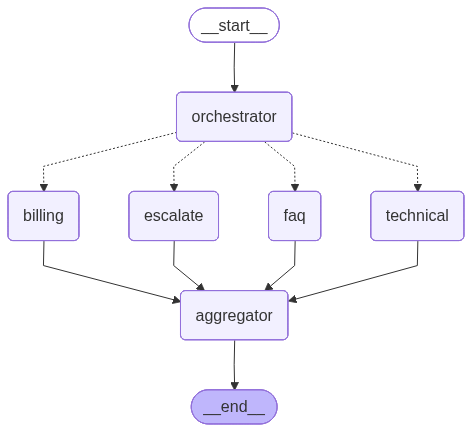

In [ ]:
from IPython.display import Image, display
Image(graph.get_graph().draw_mermaid_png())